In [67]:
import pandas as pd

import tensorflow as tf
import keras
import numpy as np
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler
#from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import train_test_split
from keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#from keras.utils.training_utils import multi_gpu_model
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras import regularizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import shap

In [68]:
#########loading data#########

!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_no_mig.csv"
!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_im.csv"
!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-observed.csv"

!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day2/Notebooks/mosquito-task2_no_mig_test.csv"
!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day2/Notebooks/mosquito-task2_im_test.csv"

--2026-03-24 11:22:29--  https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_no_mig.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 183521 (179K) [text/plain]
Saving to: ‘mosquito-task2_no_mig.csv.1’

mosquito-task2_no_m 100%[===================>] 179.22K  --.-KB/s    in 0.003s  

2026-03-24 11:22:37 (51.0 MB/s) - ‘mosquito-task2_no_mig.csv.1’ saved [183521/183521]

--2026-03-24 11:22:37--  https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_im.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubuserconten

In [69]:
Params_nomig = pd.read_csv('./mosquito-task2_no_mig.csv', sep=",").dropna()
Params_im = pd.read_csv('./mosquito-task2_im.csv', sep=",").dropna()
T_split_nomig = Params_nomig["T_split"]
SuSt_nomig = Params_nomig.iloc[:,4:]
T_split_im = Params_im["T_split"]
SuSt_im = Params_im.iloc[:,4:]

emp = pd.read_csv('./mosquito-observed.csv', sep=",")

In [70]:
emp

,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,-0.000144,0.00274,0.034471,0.053311,0.002743,0.002738,-2.050512,-2.189784


In [71]:
SuSt_nomig

,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,0.001012,0.007096,0.040893,0.049133,0.007091,0.007073,-0.052883,-0.173481
1,0.000734,0.007157,0.040620,0.048253,0.007116,0.007177,-0.019583,-0.076470
2,0.000431,0.007132,0.040480,0.048540,0.007132,0.007119,-0.001035,-0.118503
3,0.000715,0.007103,0.040480,0.049100,0.007083,0.007103,-0.023594,-0.158979
4,0.001012,0.006545,0.038933,0.047060,0.006556,0.006509,-0.146387,-0.287869
...,...,...,...,...,...,...,...,...
995,0.000394,0.007156,0.041373,0.049607,0.007158,0.007144,-0.060322,-0.172404
996,0.000950,0.006711,0.039420,0.047653,0.006702,0.006694,-0.115977,-0.244093
997,0.000509,0.007251,0.040500,0.047813,0.007221,0.007266,0.038202,-0.010829
998,0.000198,0.007014,0.039773,0.046973,0.006994,0.007028,-0.007491,-0.058398


In [72]:
SuSt_im

,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,0.000024,0.007137,0.040847,0.048800,0.007127,0.007146,-0.032829,-0.123093
1,-0.000028,0.006864,0.040713,0.049067,0.006851,0.006879,-0.148506,-0.249842
2,-0.000134,0.007193,0.041280,0.048273,0.007198,0.007192,-0.034745,-0.071310
3,-0.000057,0.006937,0.040600,0.047413,0.006938,0.006937,-0.099662,-0.125816
4,-0.000198,0.006761,0.039593,0.048173,0.006754,0.006773,-0.105415,-0.241555
...,...,...,...,...,...,...,...,...
995,0.000048,0.006902,0.041007,0.048860,0.006910,0.006891,-0.143812,-0.232458
996,-0.000036,0.006883,0.040767,0.048600,0.006872,0.006894,-0.142731,-0.215872
997,0.000318,0.006933,0.039813,0.048367,0.006927,0.006930,-0.041787,-0.186919
998,0.000023,0.006697,0.039900,0.048793,0.006698,0.006695,-0.155663,-0.310205


In [73]:
Params_nomig

,N1,N2,T_split,mig,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,75000.0,150000.0,310,0,0.001012,0.007096,0.040893,0.049133,0.007091,0.007073,-0.052883,-0.173481
1,75000.0,150000.0,223,0,0.000734,0.007157,0.040620,0.048253,0.007116,0.007177,-0.019583,-0.076470
2,75000.0,150000.0,285,0,0.000431,0.007132,0.040480,0.048540,0.007132,0.007119,-0.001035,-0.118503
3,75000.0,150000.0,333,0,0.000715,0.007103,0.040480,0.049100,0.007083,0.007103,-0.023594,-0.158979
4,75000.0,150000.0,368,0,0.001012,0.006545,0.038933,0.047060,0.006556,0.006509,-0.146387,-0.287869
...,...,...,...,...,...,...,...,...,...,...,...,...
995,75000.0,150000.0,330,0,0.000394,0.007156,0.041373,0.049607,0.007158,0.007144,-0.060322,-0.172404
996,75000.0,150000.0,343,0,0.000950,0.006711,0.039420,0.047653,0.006702,0.006694,-0.115977,-0.244093
997,75000.0,150000.0,240,0,0.000509,0.007251,0.040500,0.047813,0.007221,0.007266,0.038202,-0.010829
998,75000.0,150000.0,210,0,0.000198,0.007014,0.039773,0.046973,0.006994,0.007028,-0.007491,-0.058398


In [74]:
Params_im

,N1,N2,T_split,mig,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,75000.0,150000.0,322,0.1,0.000024,0.007137,0.040847,0.048800,0.007127,0.007146,-0.032829,-0.123093
1,75000.0,150000.0,366,0.1,-0.000028,0.006864,0.040713,0.049067,0.006851,0.006879,-0.148506,-0.249842
2,75000.0,150000.0,210,0.1,-0.000134,0.007193,0.041280,0.048273,0.007198,0.007192,-0.034745,-0.071310
3,75000.0,150000.0,200,0.1,-0.000057,0.006937,0.040600,0.047413,0.006938,0.006937,-0.099662,-0.125816
4,75000.0,150000.0,362,0.1,-0.000198,0.006761,0.039593,0.048173,0.006754,0.006773,-0.105415,-0.241555
...,...,...,...,...,...,...,...,...,...,...,...,...
995,75000.0,150000.0,347,0.1,0.000048,0.006902,0.041007,0.048860,0.006910,0.006891,-0.143812,-0.232458
996,75000.0,150000.0,347,0.1,-0.000036,0.006883,0.040767,0.048600,0.006872,0.006894,-0.142731,-0.215872
997,75000.0,150000.0,394,0.1,0.000318,0.006933,0.039813,0.048367,0.006927,0.006930,-0.041787,-0.186919
998,75000.0,150000.0,371,0.1,0.000023,0.006697,0.039900,0.048793,0.006698,0.006695,-0.155663,-0.310205


In [75]:
T_split_nomig

,T_split
0,310
1,223
2,285
3,333
4,368
...,...
995,330
996,343
997,240
998,210


In [76]:
T_split_im

,T_split
0,322
1,366
2,210
3,200
4,362
...,...
995,347
996,347
997,394
998,371


# Task 1: Perform model selection
We will compare the two models using Deep Learning.

In [84]:
# Combine all arrays.
x=np.concatenate((SuSt_nomig,SuSt_im),axis=0)

# Label each simulated array.
y=[0 for i in range(len(SuSt_nomig))]
y.extend([1 for i in range(len(SuSt_im))])
y = np.array(y)
y = np.eye(2)[y]

#Standardization of the input features with a standard scaler. This is important when working with features tht have different scales.
# The standard score of a sample x is calculated as: z = (x - u) / s
#where u is the mean of the training samples and s is the standard deviation of the training samples.
scale = StandardScaler()
SuSt = scale.fit_transform(x)

In [85]:
Y_train, Y_valid, SuSt_train, SuSt_valid = train_test_split(y,SuSt,test_size=0.25, shuffle=True)

In [79]:
def build_model():
    model = Sequential()
    model.add(Dense(128, input_dim=SuSt.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(2, activation="softmax"))
    model.summary()
    return model

In [80]:
from keras import losses

#model initiation
estimator = build_model()

# Compile the CNN.
estimator.compile(loss=keras.losses.categorical_crossentropy,
	              optimizer='Adam',
	              metrics=['accuracy'])

# We will use early stopping and save the model with the best val_accuracy.
early_stop = EarlyStopping(monitor='val_accuracy', patience=25, verbose=0, mode='max', restore_best_weights=True)
### stop training when validation error increases (wait 25 epochs to see if there is any improvement).

#display training progress for each completed epoch.
class PrintD(keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

# maximum number of EPOCHS, ie full training cycles on the whole training dataset (how many times we see the same training set)
EPOCHS = 150

#Training of the Network, with an independent validation set
history = estimator.fit(SuSt_train, Y_train, verbose = 1, epochs=EPOCHS, validation_data=(SuSt_valid, Y_valid), batch_size=32, callbacks=[early_stop, PrintD()])

from keras.models import model_from_json

model = estimator.to_json()
# save model
with open('./Trained_SuSt.json','w') as json_file:
    json_file.write(model)

# save weights
estimator.save_weights('./Trained_SuSt' +'.weights.h5')
print('model saved!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,962 (23.29 KB)

 Trainable params: 5,962 (23.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7445 - loss: 0.6529
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8813 - loss: 0.5729 - val_accuracy: 0.9580 - val_loss: 0.3586
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9673 - loss: 0.1611 - val_accuracy: 0.9680 - val_loss: 0.0843
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9727 - loss: 0.0663 - val_accuracy: 0.9760 - val_loss: 0.0869
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9740 - loss: 0.0629 - val_accuracy: 0.9680 - val_loss: 0.0847
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9727 - loss: 0.0605 - val_accuracy: 0.9700 - val_loss: 0.0763
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.0523 - val_accuracy: 0.9760 - val_loss: 0.0812
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9807 - loss: 0.0532 - val_accuracy: 0.9720 - val_loss: 0.0813
Epoch 8/150
47/47 ━━━━━━━━━━━━━━━━━━

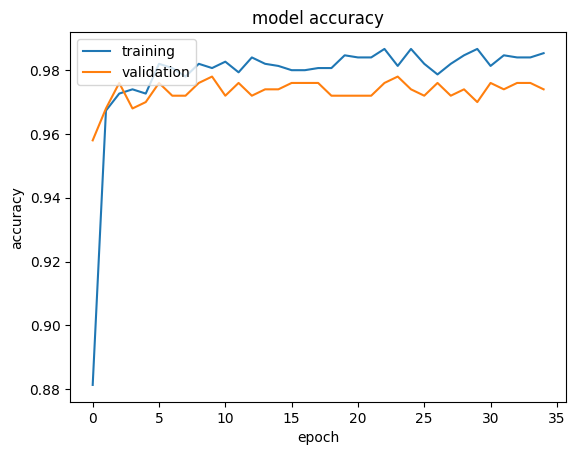

In [81]:
# Plot training and validation accuracies
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()

In [86]:
Params_nomig_test = pd.read_csv('./mosquito-task2_no_mig_test.csv', sep=",").dropna()
Params_im_test = pd.read_csv('./mosquito-task2_im_test.csv', sep=",").dropna()
T_split_nomig_test = Params_nomig_test["T_split"]
SuSt_nomig_test = Params_nomig_test.iloc[:,4:]
T_split_im_test = Params_im_test["T_split"]
SuSt_im_test = Params_im_test.iloc[:,4:]

In [87]:
# Combine all arrays.
x_test=np.concatenate((SuSt_nomig_test,SuSt_im_test),axis=0)

# Label each simulated array.
y_test=[0 for i in range(len(SuSt_nomig_test))]
y_test.extend([1 for i in range(len(SuSt_im_test))])
y_test = np.array(y_test)

#Standardization of the input features with a standard scaler. This is important when working with features tht have different scales.
# The standard score of a sample x is calculated as: z = (x - u) / s
#where u is the mean of the training samples and s is the standard deviation of the training samples.
SuSt_test = scale.transform(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


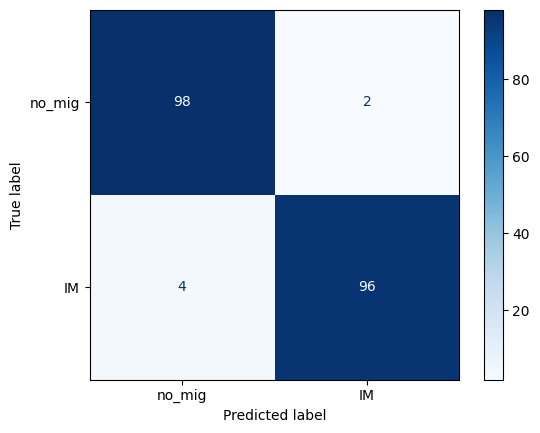

In [88]:
# Predict with the trained model and export a confusion matrix.
pred = estimator.predict(SuSt_test)
pred_cat = [i.argmax() for i in pred]
cm=confusion_matrix(y_test, pred_cat)
scenarios = ['no_mig', 'IM']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=scenarios)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [89]:
# Now predict the best model for the empirical dataset.
pred = estimator.predict(emp)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step


array([[0.78973114, 0.2102688 ]], dtype=float32)

# Task 2: parameter estimation

Now we do parameter estimation under the selected model.

In [90]:
#Standardization of the input features with a standard scaler. This is important when working with features tht have different scales.
# The standard score of a sample x is calculated as: z = (x - u) / s
#where u is the mean of the training samples and s is the standard deviation of the training samples.
scale_im = StandardScaler()
SuSt_im = scale_im.fit_transform(SuSt_im)
SuSt_im_test = scale_im.transform(SuSt_im_test)

In [91]:
def build_model():
    model = Sequential()
    model.add(Dense(128, input_dim=SuSt_im.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.summary()
    return model

In [92]:
T_split_im_train, T_split_im_valid, SuSt_im_train, SuSt_im_valid = train_test_split(T_split_im,SuSt_im,test_size=0.25, shuffle=False)

In [93]:
from keras import losses

#model initiation
estimator = build_model()

estimator.compile(loss="mean_absolute_percentage_error", optimizer = "Adam")
#early stopping to avoid overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

#display training progress for each completed epoch.
class PrintD(keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

# maximum number of EPOCHS, ie full training cycles on the whole training dataset (how many times we see the same training set)
EPOCHS = 150

#Training of the Network, with an independent validation set
history = estimator.fit(SuSt_im_train, T_split_im_train, verbose = 1, epochs=EPOCHS, validation_data=(SuSt_im_valid, T_split_im_valid), batch_size=32, callbacks=[early_stop, PrintD()])

from keras.models import model_from_json

model = estimator.to_json()
# save model
with open('./Trained_SuSt.json','w') as json_file:
    json_file.write(model)

# save weights
estimator.save_weights('./Trained_SuSt' +'.weights.h5')
print('model saved!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,953 (23.25 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 99.8731
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 99.7507 - val_loss: 99.3884
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 98.4416 - val_loss: 96.8413
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 92.3614 - val_loss: 84.7111
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 68.6019 - val_loss: 49.0983
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 41.5177 - val_loss: 38.0854
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 36.3630 - val_loss: 33.2332
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 31.2651 - val_loss: 28.1844
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 27.1047 - val_loss: 25.1032
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24.1192 - val_loss: 22.7370
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.6247 - val_loss: 20.8202
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.6624

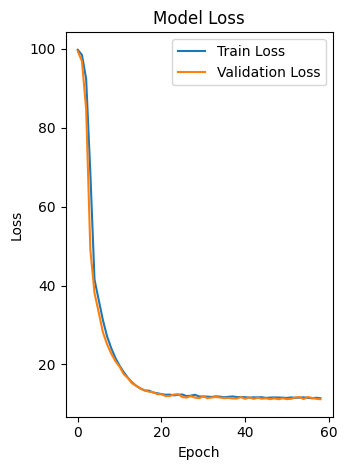

In [94]:
import matplotlib.pyplot as plt

# Plot loss history
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

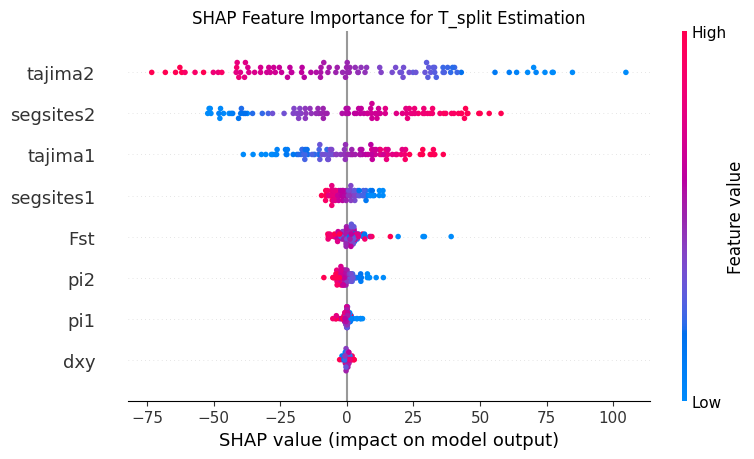

In [95]:
# We can look at summary statistics contribution too.
# background subset for speed; adjust as needed
background = shap.kmeans(SuSt_im_train, 20)

Xv = SuSt_im_test

# 1. Initialize the Explainer
# For regression, we use the model's predict function
# background is your kmeans-summarized training data
# Wrap the predict function to stay silent
explainer = shap.KernelExplainer(lambda Xv: estimator.predict(Xv, verbose=0), background)

# 2. Calculate SHAP values
# Xv should be your test summary statistics
shap_values = explainer.shap_values(Xv, silent=True)

# --- SHAPE FIX FOR REGRESSION ---
# If SHAP returns a list [array] for a single-output regression:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# If Keras/SHAP produces a (samples, features, 1) array:
if len(shap_values.shape) == 3:
    shap_values = shap_values.reshape(shap_values.shape[0], shap_values.shape[1])
# --------------------------------

# 3. Match the DataFrame columns
# Ensure 'emp' is the original dataframe containing the feature names
Xv_df = pd.DataFrame(Xv, columns=emp.columns)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 8))

plt.title("SHAP Feature Importance for T_split Estimation")
plt.tight_layout()
shap.summary_plot(
            shap_values,
            Xv_df,
            max_display=20,
            show=True
        )

plt.title(f"SHAP Summary")
plt.tight_layout()
plt.close()

ABC Prediction Error (E_pred): 0.5182


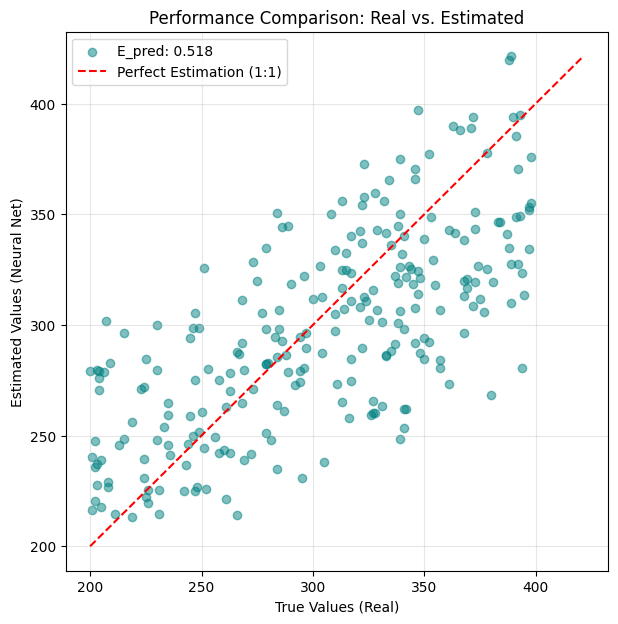

In [96]:
# 1. Get Predictions
Y_pred = estimator.predict(SuSt_im_valid, verbose=0).flatten()
Y_true = T_split_im_valid

# 2. Calculate "abc-style" Prediction Error
# Formula: Sum((true - pred)^2) / Sum((true - mean_true)^2)
mse_sum = np.sum((Y_true - Y_pred)**2)
var_sum = np.sum((Y_true - np.mean(Y_true))**2)
prediction_error = mse_sum / var_sum

print(f"ABC Prediction Error (E_pred): {prediction_error:.4f}")

# 3. Parity Plot (Real vs. Estimated)
plt.figure(figsize=(7, 7))
plt.scatter(Y_true, Y_pred, alpha=0.5, color='teal', label=f'E_pred: {prediction_error:.3f}')

# Add 1:1 Identity Line
limits = [min(min(Y_true), min(Y_pred)), max(max(Y_true), max(Y_pred))]
plt.plot(limits, limits, color='red', linestyle='--', label='Perfect Estimation (1:1)')

plt.xlabel('True Values (Real)')
plt.ylabel('Estimated Values (Neural Net)')
plt.title('Performance Comparison: Real vs. Estimated')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [97]:
# Now predict T_split for the empirical dataset.
pred = estimator.predict(emp)
pred * 10

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[3422.6768]], dtype=float32)